In [1]:
# import numpy as np
# import pandas as pd
# import math
# import os
# import glob
# import matplotlib.pyplot as plt
# import ipywidgets as widgets
# from IPython.display import clear_output, display
# from scipy.signal import find_peaks  # 新增：用于特征提取

# # 显式声明模式
# %matplotlib inline 

# # ==========================================
# # 1. 基础路径配置与数据持久化加载
# # ==========================================
# base_path = r'D:\code\data\green'
# # base_path = "D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/"
# search_pattern = os.path.join(base_path, '202*.csv')
# file_list = sorted(glob.glob(search_pattern))

# if not file_list:
#     print("❌ 未找到数据文件，请检查路径！")
# else:
#     print("⏳ 正在读取并拼接原始 CSV 数据，请稍候...")
#     df_list = [pd.read_csv(f) for f in file_list]
#     df = pd.concat(df_list, ignore_index=True)
    
#     # 清理多余列并处理缺失值
#     columns_to_drop = ['clean_green1', 'butter_green1']
#     df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')
#     df['green1'] = df['green1'].ffill().fillna(0)  

#     # 反转信号极性
#     INVERT_POLARITY = True
#     polarity_multiplier = -1.0 if INVERT_POLARITY else 1.0
#     raw_signal = df['green1'].values * polarity_multiplier
    
#     total_points = len(raw_signal)
#     fs = 100  # 采样率 100Hz
#     print(f"✅ 数据加载就绪！总行数: {total_points}，总时长: {total_points/fs:.1f} 秒")

In [2]:
# df['motion'] = np.linalg.norm(df[['accX', 'accY', 'accZ']], axis=1)
# df['motion'] = df["motion"].fillna(2048).to_numpy().astype(int)

# inst_motion = (df["motion"] - 2048).abs()
# threshold = 200
# inst_motion_clean = inst_motion.where(inst_motion > threshold, 0)
# df[f"motion_{threshold}"] = inst_motion_clean

# # 4. 窗口聚合 (降采样)
# # 对清理后的绝对运动量求均值
# y = inst_motion_clean.groupby(inst_motion_clean.index // 100).mean()
# # 查看分布
# y.hist(bins=200)

In [3]:
# df["Datetime"] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M:%S')
# df.drop(['Date', 'Time', 'Duration',"accX", "accY", "accZ"], axis=1, inplace=True)

In [4]:
# df.to_csv("ring.csv", index=False)

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


In [6]:
df = pd.read_csv("ring.csv")

In [7]:
df.head(5)

,green1,green2,ir1,ir2,motion,motion_200,Datetime
0,8715406.0,8502910.0,9946705.0,9762970.0,2091,0,2026-06-10 11:31:23
1,8716251.0,8503157.0,9947373.0,9763589.0,2078,0,2026-06-10 11:31:23
2,8715944.0,8503201.0,9947881.0,9763737.0,2011,0,2026-06-10 11:31:23
3,8715814.0,8503174.0,9948173.0,9764195.0,1995,0,2026-06-10 11:31:23
4,8715142.0,8503446.0,9948311.0,9764283.0,1990,0,2026-06-10 11:31:23


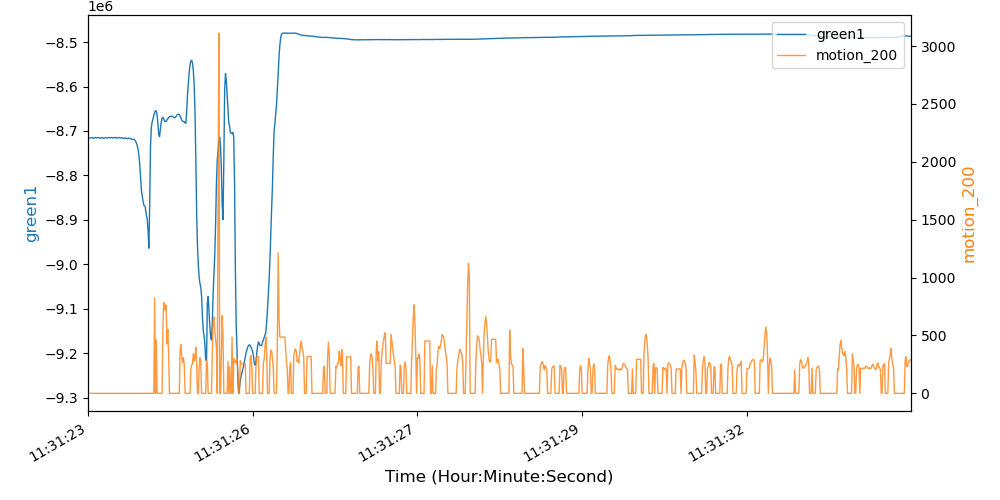

In [8]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ipywidgets import interact, IntSlider, Layout
import ipywidgets as widgets

# 【关键保障】确保数据有 Datetime 列，且索引为默认的纯数字整数
# 如果之前把 Datetime 设为了索引，这里把它还原回普通列
if 'Datetime' not in df.columns and df.index.name == 'Datetime':
    df = df.reset_index()

col_y1 = 'green1'
col_y2 = 'motion_200' 

# ----------------- 1. 初始化图表 -----------------
fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')
ax2 = ax1.twinx() 

line1, = ax1.plot([], [], color='#1f77b4', label=col_y1, linewidth=1)
line2, = ax2.plot([], [], color='#ff7f0e', label=col_y2, linewidth=1, alpha=0.8)

# 【核心修复】：自定义 X 轴时间格式化器
def format_x_tick(x, pos):
    """
    当 Matplotlib 需要在 X 轴的坐标 x 处画刻度时，调用此函数
    我们把坐标 x 转换回 df 的行号，然后提取对应的 Datetime
    """
    idx = int(x)
    # 确保索引不越界
    if 0 <= idx < len(df):
        val = df['Datetime'].iloc[idx]
        if isinstance(val, str):
            # 如果是原生的字符串 '2026-06-10 11:31:23'，直接切分取后面部分
            return val.split(' ')[-1]
        elif pd.notna(val):
            # 如果已经被转成了 pd.Timestamp，格式化输出
            return val.strftime('%H:%M:%S')
    return ""

# 拦截 X 轴刻度，注入自定义函数
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(format_x_tick))
fig.autofmt_xdate() # 保持倾斜防止重叠

ax1.set_xlabel('Time (Hour:Minute:Second)', fontsize=12)
ax1.set_ylabel(col_y1, color='#1f77b4', fontsize=12)
ax2.set_ylabel(col_y2, color='#ff7f0e', fontsize=12)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
fig.canvas.header_visible = False 

# ----------------- 2. 定义交互逻辑 -----------------
MAX_RENDER_POINTS = 2000 

def update_plot(start_idx, window_size):
    end_idx = min(start_idx + window_size, len(df))
    sub_df = df.iloc[start_idx:end_idx]
    
    if sub_df.empty or len(sub_df) < 2:
        return
        
    step = max(1, len(sub_df) // MAX_RENDER_POINTS)
    plot_df = sub_df.iloc[::step]
    
    # 直接使用原始的整数索引作为画图的 X 轴
    x_data = plot_df.index
    y1_data = -1. * plot_df[col_y1].values
    y2_data = plot_df[col_y2].values
    
    line1.set_data(x_data, y1_data)
    line2.set_data(x_data, y2_data)
    
    ax1.set_xlim(x_data.min(), x_data.max())
    
    y1_min, y1_max = np.nanmin(y1_data), np.nanmax(y1_data)
    y2_min, y2_max = np.nanmin(y2_data), np.nanmax(y2_data)
    
    y1_margin = (y1_max - y1_min) * 0.05 if y1_max != y1_min else 1
    y2_margin = (y2_max - y2_min) * 0.05 if y2_max != y2_min else 1
    
    ax1.set_ylim(y1_min - y1_margin, y1_max + y1_margin)
    ax2.set_ylim(y2_min - y2_margin, y2_max + y2_margin)
    
    fig.canvas.draw_idle()

# ----------------- 3. 绑定控件并显示 -----------------
start_slider = IntSlider(
    min=0, 
    max=max(0, len(df) - 1000), 
    step=2000, 
    value=0,
    description='Start Pos:',
    layout=Layout(width='800px'),
    continuous_update=False 
)

window_slider = IntSlider(
    min=1000, 
    max=500000, 
    step=5000, 
    value=1000, 
    description='Window Size:',
    layout=Layout(width='800px'),
    continuous_update=False 
)

update_plot(0, 50000)

# 【核心修复】：使用 widgets.interactive 代替 interact
interactive_plot = widgets.interactive(update_plot, start_idx=start_slider, window_size=window_slider)

# 用 VBox 将图表和交互控件打包，只 display 一次
ui = widgets.VBox([fig.canvas, interactive_plot])
display(ui)

In [16]:
##### %matplotlib widget
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ipywidgets import interact, IntSlider, FloatSlider, Layout
import ipywidgets as widgets
from datetime import datetime, timedelta
from scipy.signal import butter, filtfilt, detrend
from scipy.fft import rfft, rfftfreq
from scipy.signal.windows import hann

# ==============================================================================
# Part 0: 生成模拟测试数据 (确保代码独立可运行)
# ==============================================================================
if 'df' not in locals():
    print("未检测到外部 df，正在生成合成测试数据...")
    fs = 100
    n_pts = 30000
    t = np.arange(n_pts) / fs
    # 模拟正常的 PPG 信号 (负向)
    clean_ppg = -20000 * np.sin(2 * np.pi * 1.2 * t)
    # 模拟极其剧烈的基线漂移 (爬坡) 和高频噪声
    baseline_wander = -150000 * np.sin(2 * np.pi * 0.05 * t)
    noise = np.random.randn(n_pts) * 2000
    
    # 制造一段长达 10 秒的严重脏数据 (Garbage Segment)，测试 SQI 拦截
    dirty_start, dirty_end = 10000, 11000
    noise[dirty_start:dirty_end] += np.random.randn(1000) * 30000
    
    green2 = clean_ppg + baseline_wander + noise
    
    start_time = datetime(2026, 6, 10, 11, 31, 23)
    datetimes = [start_time + timedelta(milliseconds=10*i) for i in range(n_pts)]
    
    df = pd.DataFrame({
        'green2': green2,
        'motion_200': np.clip(np.random.randn(n_pts)*10, -200, 200),
        'Datetime': [dt.strftime('%Y-%m-%d %H:%M:%S') for dt in datetimes],
        'Date': [dt.strftime('%Y-%m-%d') for dt in datetimes],
        'Time': [dt.strftime('%H:%M:%S') for dt in datetimes]
    })

# ==============================================================================
# Part 1: SQI 质检与带通滤波 (提取基础分数，不硬截断)
# ==============================================================================

def check_sqi_value(signal_chunk, fs=100):
    """计算并返回分段信号的纯数字 SQI 分数"""
    clean_signal = detrend(signal_chunk)
    windowed = clean_signal * hann(len(clean_signal))
    yf = np.abs(rfft(windowed))
    xf = rfftfreq(len(clean_signal), 1/fs)
    
    valid_idx = np.where((xf >= 0.5) & (xf <= 3.5))[0]
    all_idx = np.where((xf >= 0.1) & (xf <= 10.0))[0]
    
    hr_power = np.sum(yf[valid_idx])
    total_power = np.sum(yf[all_idx])
    
    return hr_power / (total_power + 1e-6)

def preprocess_stream_simulation(df, fs=100):
    """
    1. 清理 NaN/Inf，翻转极性，并且强力去除初始基线
    2. 计算滑动窗口 SQI 分数并赋给每一行，供后期动态过滤
    3. 运用零相移 Butterworth 滤波器提取纯净脉搏
    """
    sanitized_signal = df['green2'].replace([np.inf, -np.inf], np.nan).ffill().bfill()
    
    # 【修复核心 1】：翻转后直接去趋势（去均值）。
    # 这能避免 800 万的直流偏置灌入滤波器时，产生长达数秒的十万级边缘振荡假峰！
    inverted = sanitized_signal.values * -1.0
    inverted_detrended = detrend(inverted)
    
    df['green2_inverted'] = inverted_detrended
    df['sqi_value'] = 1.0 # 默认满分
    
    window_size = 1024
    step_size = 256
    
    # 计算并分配 SQI 分数
    for start in range(0, len(df) - window_size, step_size):
        chunk = df['green2_inverted'].values[start:start + window_size]
        sqi = check_sqi_value(chunk, fs=fs)
        df.loc[start:start + step_size, 'sqi_value'] = sqi
            
    b, a = butter(4, [0.5, 4.0], btype='bandpass', fs=fs)
    df['green2_filtered'] = filtfilt(b, a, df['green2_inverted'].values)
    
    return df

# ==============================================================================
# Part 2: 基于零点交叉与动态迟滞的新型状态机 (带自愈防死锁机制)
# ==============================================================================

def process_ppg_pipeline_commercial(df, sampling_rate_hz=100):
    time_per_point_ms = 1000.0 / sampling_rate_hz 
    
    PHASE_WAITING_FOR_PEAK = 1
    PHASE_WAITING_FOR_VALLEY = 0
    current_phase = PHASE_WAITING_FOR_VALLEY
    
    ac_y_history = df['green2_filtered'].values
    
    # 避开前 1000 个点的潜在不稳定期来估算初始振幅
    initial_std = np.std(ac_y_history[1000:2000]) if len(ac_y_history) > 2000 else np.std(ac_y_history)
    if initial_std == 0 or np.isnan(initial_std): initial_std = 1000.0
    
    avg_amp = initial_std * 3.0
    hysteresis = avg_amp * 0.15 
    
    local_max = float('-inf'); local_max_x = 0
    local_min = float('inf'); local_min_x = 0
    v1_x = 0; v1_y = 0.0
    precise_v1_x = 0.0 
    
    baseline_rri = 0.0       
    display_hr_state = 0.0   
    rri_miss_count = 0 
    
    extracted_features = []

    for i in range(len(ac_y_history)):
        ac_y = ac_y_history[i]

        # 【修复核心 2：防死锁自愈机制】
        # 每处理一个点，让迟滞门槛缓慢衰减。0.995 意味着约 1.5 秒后门槛减半。
        # 即使刚才有几万幅度的运动伪影撑爆了门槛，只要它过去了，门槛会迅速回落去抓取正常的小心跳。
        hysteresis = max(hysteresis * 0.995, 10.0)

        if current_phase == PHASE_WAITING_FOR_VALLEY:
            if ac_y < local_min:
                local_min = ac_y
                local_min_x = i
            
            # 【找谷逻辑】：穿过 0 轴向上，且高于谷底一个迟滞幅度
            if ac_y > 0 and ac_y > (local_min + hysteresis):
                v2_x = local_min_x
                v2_y = local_min
                
                current_amp = local_max - local_min if local_max != float('-inf') else avg_amp
                
                # 【修复核心 3：单点抗爆】限制单次超大假峰对平均值的影响（最高不超过当前均值的 3 倍）
                current_amp = min(current_amp, avg_amp * 3.0)
                
                avg_amp = avg_amp * 0.90 + current_amp * 0.10
                hysteresis = max(avg_amp * 0.15, 10.0)
                
                # 抛物线亚采样精确插值
                if 0 < v2_x < len(df) - 1:
                    y_m1, y_0, y_p1 = ac_y_history[v2_x-1], ac_y_history[v2_x], ac_y_history[v2_x+1]
                    denom = y_m1 - 2 * y_0 + y_p1
                    delta_x = 0.5 * (y_m1 - y_p1) / denom if denom != 0 else 0.0
                    delta_x = max(-1.0, min(1.0, delta_x))
                else: delta_x = 0.0
                
                precise_v2_x = float(v2_x) + delta_x
                
                if precise_v1_x > 0.0:
                    rri_ms = (precise_v2_x - precise_v1_x) * time_per_point_ms
                    
                    if 300 <= rri_ms <= 2500:
                        if baseline_rri == 0.0: 
                            baseline_rri = rri_ms
                            display_hr_state = 60000.0 / rri_ms
                            
                        is_valid_beat = (0.45 * baseline_rri) <= rri_ms <= (1.8 * baseline_rri)
                        
                        # 连续异常重置基准
                        if not is_valid_beat:
                            rri_miss_count += 1
                            if rri_miss_count > 3:
                                baseline_rri = rri_ms
                                is_valid_beat = True
                        else:
                            rri_miss_count = 0
                            
                        if is_valid_beat:
                            raw_hr = 60000.0 / rri_ms
                            baseline_rri = baseline_rri * 0.75 + rri_ms * 0.25
                            display_hr_state = display_hr_state * 0.85 + raw_hr * 0.15
                            
                            area_up = np.sum(ac_y_history[v1_x : local_max_x]) if v1_x < local_max_x else 0
                            area_down = np.sum(np.abs(ac_y_history[local_max_x : v2_x])) if local_max_x < v2_x else 0

                            row_dt = df.loc[i, 'Datetime']
                            extracted_features.append({
                                'datetime': row_dt if pd.notna(row_dt) else f"Point_{i}",
                                'rri_raw': round(rri_ms, 2),                 
                                'hr_raw': round(raw_hr, 1),             
                                'hr_display': int(display_hr_state),    
                                'area_up': int(area_up),     
                                'area_down': int(area_down), 
                                'peak_idx': int(local_max_x), 
                                'valley_idx': int(v2_x)
                            })

                precise_v1_x = precise_v2_x 
                v1_x = v2_x
                local_max = float('-inf')
                current_phase = PHASE_WAITING_FOR_PEAK

        elif current_phase == PHASE_WAITING_FOR_PEAK:
            if ac_y > local_max:
                local_max = ac_y
                local_max_x = i
            
            # 【找峰逻辑】：穿过 0 轴向下，且低于峰顶一个迟滞幅度
            if ac_y < 0 and ac_y < (local_max - hysteresis):
                local_min = float('inf')
                current_phase = PHASE_WAITING_FOR_VALLEY

    return pd.DataFrame(extracted_features)

sampling_rate_hz = 100

# ==============================================================================
# Part 3: Combine Visualization with Peak Marker Pipeline
# ==============================================================================

print("正在执行 SQI 流式预处理与 Butterworth 滤波...")
df = preprocess_stream_simulation(df, fs=sampling_rate_hz)

print("正在提取特征波峰...")
all_features_df = process_ppg_pipeline_commercial(df, sampling_rate_hz=sampling_rate_hz)
print(f"基础提取完成！池中共缓存了 {len(all_features_df)} 个候选心跳。")

# 可视化直接映射已经去噪、调正好的滤波信号
col_y1 = 'green2_filtered' 
col_y2 = 'motion_200' 

fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')
ax2 = ax1.twinx() 

line1, = ax1.plot([], [], color='#1f77b4', label='Filtered PPG', linewidth=1)
line2, = ax2.plot([], [], color='#ff7f0e', label=col_y2, linewidth=1, alpha=0.8)

peaks_line, = ax1.plot([], [], 'ro', label='Peak (Pass SQI)', markersize=4)
valleys_line, = ax1.plot([], [], 'bx', label='Valley', markersize=4)

def format_x_tick(x, pos):
    idx = int(x)
    if 0 <= idx < len(df):
        val = df['Datetime'].iloc[idx]
        if isinstance(val, str): return val.split(' ')[-1]
        elif pd.notna(val): return val.strftime('%H:%M:%S')
    return ""

ax1.xaxis.set_major_formatter(ticker.FuncFormatter(format_x_tick))
fig.autofmt_xdate()

ax1.set_xlabel('Time (Hour:Minute:Second)', fontsize=12)
ax1.set_ylabel('IIR Filtered PPG Signal', color='#1f77b4', fontsize=12)
ax2.set_ylabel(col_y2, color='#ff7f0e', fontsize=12)

lines = [line1, line2, peaks_line, valleys_line]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')
plt.tight_layout()
fig.canvas.header_visible = False 

# ==============================================================================
# Part 4: Interactive Update Logic (带动态 SQI 滑动条)
# ==============================================================================

MAX_RENDER_POINTS = 2000 

def update_plot(start_idx, window_size, sqi_threshold):
    end_idx = min(start_idx + window_size, len(df))
    sub_df = df.iloc[start_idx:end_idx]
    
    if sub_df.empty or len(sub_df) < 2: return
    
    step = max(1, len(sub_df) // MAX_RENDER_POINTS)
    plot_df = sub_df.iloc[::step]
    
    x_data = plot_df.index
    y1_data = plot_df[col_y1].values
    y2_data = plot_df[col_y2].values
    
    line1.set_data(x_data, y1_data)
    line2.set_data(x_data, y2_data)
    
    # 计算本可视窗口内的平均 SQI 质量
    window_mean_sqi = sub_df['sqi_value'].mean()
    
    if not all_features_df.empty:
        sub_features = all_features_df[(all_features_df['peak_idx'] >= start_idx) & (all_features_df['peak_idx'] < end_idx)]
        
        # 【核心调参逻辑】：根据用户选择的 SQI 阈值，动态决定哪些心跳点被保留
        valid_indices = []
        for idx in sub_features.index:
            p_idx = sub_features.loc[idx, 'peak_idx']
            if df.loc[p_idx, 'sqi_value'] >= sqi_threshold:
                valid_indices.append(idx)
                
        valid_features = sub_features.loc[valid_indices]
        
        peaks_line.set_data(valid_features['peak_idx'], df.loc[valid_features['peak_idx'], col_y1])
        valleys_line.set_data(valid_features['valley_idx'], df.loc[valid_features['valley_idx'], col_y1])
    else:
        peaks_line.set_data([], [])
        valleys_line.set_data([], [])
    
    ax1.set_xlim(x_data.min(), x_data.max())
    y1_min, y1_max = np.nanmin(y1_data), np.nanmax(y1_data)
    y2_min, y2_max = np.nanmin(y2_data), np.nanmax(y2_data)
    
    y1_margin = (y1_max - y1_min) * 0.05 if y1_max != y1_min else 1
    y2_margin = (y2_max - y2_min) * 0.05 if y2_max != y2_min else 1
    
    ax1.set_ylim(y1_min - y1_margin, y1_max + y1_margin)
    ax2.set_ylim(y2_min - y2_margin, y2_max + y2_margin)
    
    if window_mean_sqi < sqi_threshold:
        ax1.set_facecolor('#fff0f0') 
        ax1.set_title(f'⚠️ High Noise (Window SQI: {window_mean_sqi:.3f} < Thresh: {sqi_threshold:.3f})', color='red')
    else:
        ax1.set_facecolor('#ffffff')
        ax1.set_title(f'Clean Window (Mean SQI: {window_mean_sqi:.3f})', color='black')
        
    fig.canvas.draw_idle()

# ==============================================================================
# Part 5: Widgets and Display
# ==============================================================================

start_slider = IntSlider(
    min=0, max=max(0, len(df) - 1000), step=1000, value=0,
    description='Start Pos:', layout=Layout(width='800px'), continuous_update=False 
)
window_slider = IntSlider(
    min=1000, max=min(500000, len(df)), step=2000, value=min(10000, len(df)),
    description='Window Size:', layout=Layout(width='800px'), continuous_update=False 
)
sqi_slider = FloatSlider(
    min=0.0, max=0.5, step=0.01, value=0.03,
    description='SQI Threshold:', layout=Layout(width='800px'), continuous_update=False,
    style={'description_width': 'initial'}
)

update_plot(start_slider.value, window_slider.value, sqi_slider.value)
interactive_plot = widgets.interactive(update_plot, start_idx=start_slider, window_size=window_slider, sqi_threshold=sqi_slider)
ui = widgets.VBox([fig.canvas, interactive_plot])
display(ui)

正在执行 SQI 流式预处理与 Butterworth 滤波...
正在提取特征波峰...
基础提取完成！池中共缓存了 85685 个候选心跳。


In [10]:
df_sliced = df[df['Datetime'].between('2026-06-10 11:31:23', '2026-06-10 11:32:58')]

In [11]:
df_sliced

,green1,green2,ir1,ir2,motion,motion_200,Datetime,green2_inverted,sqi_value,green2_filtered
0,8715406.0,8502910.0,9946705.0,9762970.0,2091,0,2026-06-10 11:31:23,2.575486e+06,0.425044,-64315.167620
1,8716251.0,8503157.0,9947373.0,9763589.0,2078,0,2026-06-10 11:31:23,2.575239e+06,0.425044,-65661.778180
2,8715944.0,8503201.0,9947881.0,9763737.0,2011,0,2026-06-10 11:31:23,2.575195e+06,0.425044,-66964.636780
3,8715814.0,8503174.0,9948173.0,9764195.0,1995,0,2026-06-10 11:31:23,2.575222e+06,0.425044,-68221.439484
4,8715142.0,8503446.0,9948311.0,9764283.0,1990,0,2026-06-10 11:31:23,2.574950e+06,0.425044,-69429.377044
...,...,...,...,...,...,...,...,...,...,...
6635,8486094.0,10229250.0,11294101.0,11446484.0,2207,0,2026-06-10 11:32:58,8.490058e+05,0.622299,16121.225237
6636,8486043.0,10229396.0,11294628.0,11446638.0,2207,0,2026-06-10 11:32:58,8.488598e+05,0.622299,15919.020073
6637,8485932.0,10229669.0,11295148.0,11446992.0,2207,0,2026-06-10 11:32:58,8.485867e+05,0.622299,15621.188323
6638,8485992.0,10229831.0,11295550.0,11447031.0,2207,0,2026-06-10 11:32:58,8.484247e+05,0.622299,15245.088333


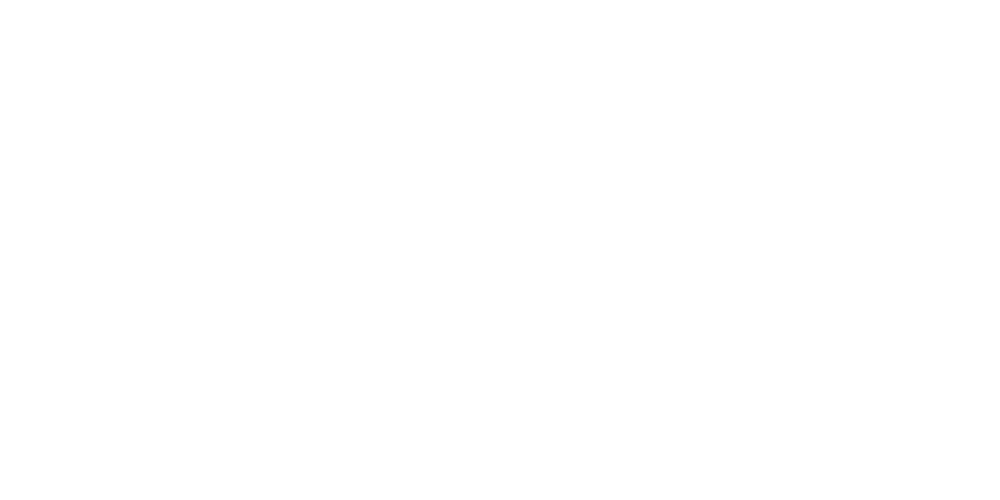

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.signal.windows import hann

# 假设你的采样率还是 100 Hz
sampling_rate_hz = 100 

# 1. 提取信号
# 注意：之前我们讨论过绿光硬件极性反转，这里如果是看频率幅度，正负无所谓，但统一习惯乘个 -1
signal = df_sliced['green1'].values * -1.0  

# 2. 核心预处理：去均值（消除 0Hz 的直流基线影响）
signal_detrended = signal - np.mean(signal)

# 3. 加窗：由于截取的是非整周期信号，两端会产生阶跃，加汉宁窗(Hanning)消除频谱泄漏
# 如果你不想加窗，可以把这行注释掉，直接传 signal_detrended 给 FFT
window = hann(len(signal_detrended))
signal_windowed = signal_detrended * window

# 4. 执行实数快速傅里叶变换 (rfft)
# rfft 专门用于纯实数信号，只返回正频率部分，计算速度快一倍
N = len(signal_windowed)
yf = rfft(signal_windowed)
xf = rfftfreq(N, 1 / sampling_rate_hz) # 生成对应的 X 轴频率坐标 (Hz)

# 计算幅值 (Magnitude)
# 乘 2/N 是为了还原真实的物理幅值
amplitude = 2.0 / N * np.abs(yf)

# 5. 可视化
fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')

# 画出频谱图
ax1.plot(xf, amplitude, color='#2ca02c')
ax1.set_title('FFT Spectrum of PPG Signal (green1)', fontsize=14)
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)

# PPG 信号（心率）的有效频率通常在 0.5 Hz (30 BPM) 到 3.5 Hz (210 BPM) 之间
# 我们把 X 轴放大到这个关键区间，屏蔽掉高频噪声
ax1.set_xlim(0, 5) 

# 开启网格线，方便读数
ax1.grid(True, linestyle='--', alpha=0.6)

# --- 进阶附加：自动寻找心率基频 ---
# 在 0.5Hz 到 3.5Hz 范围内寻找最大峰值
valid_idx = np.where((xf >= 0.5) & (xf <= 3.5))[0]
if len(valid_idx) > 0:
    max_amp_idx = valid_idx[np.argmax(amplitude[valid_idx])]
    dominant_freq = xf[max_amp_idx]
    heart_rate_bpm = dominant_freq * 60
    
    # 在图上标出心率基频点
    ax1.plot(dominant_freq, amplitude[max_amp_idx], 'ro')
    ax1.annotate(f'HR: {heart_rate_bpm:.1f} BPM ({dominant_freq:.2f} Hz)', 
                 xy=(dominant_freq, amplitude[max_amp_idx]), 
                 xytext=(dominant_freq + 0.2, amplitude[max_amp_idx]),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=5),
                 fontsize=11, color='red', weight='bold')

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from scipy.fft import rfft, rfftfreq
from scipy.signal.windows import hann
from scipy.signal import detrend

def extract_fft_features(signal_slice, fs=100, min_hz=0.5, max_hz=3.5):
    """
    纯数值方式提取 PPG 信号的频域特征
    """
    # 1. 高级去趋势：不仅去均值，还去线性斜率 (消除极低频巨峰)
    signal_detrended = detrend(signal_slice)
    
    # 2. 加窗
    window = hann(len(signal_detrended))
    signal_windowed = signal_detrended * window
    
    # 3. FFT 计算
    N = len(signal_windowed)
    yf = rfft(signal_windowed)
    xf = rfftfreq(N, 1 / fs)
    amplitude = (2.0 / N) * np.abs(yf)
    
    # 4. 锁定生理心率区间 (0.5Hz - 3.5Hz)
    valid_idx = np.where((xf >= min_hz) & (xf <= max_hz))[0]
    
    if len(valid_idx) == 0:
        return {"Error": "No valid frequency bins found."}
        
    valid_xf = xf[valid_idx]
    valid_amp = amplitude[valid_idx]
    
    # 5. 提取特征数值
    max_idx = np.argmax(valid_amp)
    dominant_freq = valid_xf[max_idx]
    peak_amplitude = valid_amp[max_idx]
    
    # 计算信噪比/信号纯度 (SQI: Signal Quality Index)
    # 算法：最大峰值的能量 / 整个有效频段内的总能量 (越接近 1 说明信号越干净)
    total_band_power = np.sum(valid_amp)
    sqi = (peak_amplitude / total_band_power) if total_band_power > 0 else 0
    
    return {
        "HR_BPM": round(dominant_freq * 60, 1),
        "Frequency_Hz": round(dominant_freq, 3),
        "Peak_Amplitude": round(peak_amplitude, 1),
        "Signal_Quality": round(sqi, 3) # 建议阈值：> 0.15 算是不错的信号
    }

# ==========================================
# 调用示例
# ==========================================
# 假设 df_sliced 是你的切片数据
raw_signal = df_sliced['green1'].values * -1.0 
features = extract_fft_features(raw_signal, fs=100)

print(f"提取结果: {features}")

提取结果: {'HR_BPM': np.float64(30.7), 'Frequency_Hz': np.float64(0.512), 'Peak_Amplitude': np.float64(188.6), 'Signal_Quality': np.float64(0.028)}


In [14]:
# # %matplotlib widget
# import math
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
# from ipywidgets import interact, IntSlider, Layout
# import ipywidgets as widgets
# from datetime import datetime, timedelta

# # ==============================================================================
# # Part 1: Utility and Core Processing Functions (Provided by User)
# # ==============================================================================

# def c_style_median_of_3(a, b, c):
#     """C-style median of three values."""
#     if a > b:
#         if b > c:
#             return b
#         elif a > c:
#             return c
#         else:
#             return a
#     else:
#         if a > c:
#             return a
#         elif b > c:
#             return c
#         else:
#             return b

# def process_ppg_pipeline_commercial(df, sampling_rate_hz=100):
#     """
#     User-provided PPG feature extraction function that identifies
#     peaks and valleys, and returns a DataFrame of features including
#     peak_idx and valley_idx.
#     """
#     MAX_SLEW_RATE = 50000.0
#     DC_ALPHA = 0.95
#     time_per_point_ms = 1000.0 / sampling_rate_hz 
    
#     prev_clean_y = None
#     ring_buf = [0.0, 0.0, 0.0]
#     buf_idx = 0
#     buf_filled = False
#     prev_raw_dc = None
#     prev_ac_y = 0.0
    
#     PHASE_WAITING_FOR_PEAK = 1
#     PHASE_WAITING_FOR_VALLEY = 0
#     current_phase = PHASE_WAITING_FOR_VALLEY
    
#     # [Relaxation 1] allow weaker pulse signals through
#     upper_th = 5000.0; lower_th = -5000.0; MIN_AC_AMP = 500.0
    
#     local_max = float('-inf'); local_max_x = 0
#     local_min = float('inf'); local_min_x = 0
#     v1_x = 0; v1_y = 0.0
    
#     # [New] Precise (decimal) position of the previous valley bottom
#     precise_v1_x = 0.0 
    
#     run_sum = 0.0; run_enmo = 0.0; run_pts = 0
#     snap_area = 0.0; snap_enmo = 0.0; snap_pts = 0
#     area_up_saved = 0.0
    
#     baseline_rri = 0.0       
#     display_hr_state = 0.0   
#     baseline_1g = 0.0
    
#     extracted_features = []
    
#     # [New] Initialize history of AC signal for interpolation backtrace
#     ac_y_history = np.zeros(len(df))

#     # ENMO is missing from this processing loop. Mock it to be consistent with another version.
#     # We will assume a constant low level of ENMO and baseline_1g for this pipeline.
#     # The visualization uses motion_200 as its data.

#     for i, row in enumerate(df.itertuples()):
#         # 【Correct hardware polarity inversion】
#         raw_y = float(row.green2) * -1.0
        
#         # MOCK missing ACC data for consistency with pipeline logic, but don't use it.
#         acc_x, acc_y, acc_z = 0, 0, 0 # float(row.accX), float(row.accY), float(row.accZ)
#         if math.isnan(acc_x) or math.isnan(acc_y) or math.isnan(acc_z):
#              acc_norm = baseline_1g if baseline_1g != 0.0 else 2000.0 
#         else:
#              acc_norm = math.sqrt(acc_x**2 + acc_y**2 + acc_z**2)
        
#         if baseline_1g == 0.0:
#              baseline_1g = acc_norm
            
#         enmo = abs(acc_norm - baseline_1g)
#         if enmo < 300.0:
#              baseline_1g = baseline_1g * 0.99 + acc_norm * 0.01
        
#         if prev_clean_y is None: clamped_y = raw_y
#         else:
#             diff = raw_y - prev_clean_y
#             if diff > MAX_SLEW_RATE: clamped_y = prev_clean_y + MAX_SLEW_RATE
#             elif diff < -MAX_SLEW_RATE: clamped_y = prev_clean_y - MAX_SLEW_RATE
#             else: clamped_y = raw_y
#         prev_clean_y = clamped_y
        
#         ring_buf[buf_idx] = clamped_y
#         buf_idx = (buf_idx + 1) % 3
#         buf_filled = buf_filled or (buf_idx == 0)
#         final_raw_y = c_style_median_of_3(ring_buf[0], ring_buf[1], ring_buf[2]) if buf_filled else clamped_y
            
#         if prev_raw_dc is None: 
#             prev_raw_dc = final_raw_y
#             ac_y = 0.0
#         else: 
#             ac_y = final_raw_y - prev_raw_dc + DC_ALPHA * prev_ac_y
#         prev_raw_dc = final_raw_y
#         prev_ac_y = ac_y
        
#         # [New] Record current AC signal for peak search backtrace
#         ac_y_history[i] = ac_y

#         upper_th -= (upper_th / 256.0)
#         lower_th -= (lower_th / 256.0)
#         if upper_th < MIN_AC_AMP: upper_th = MIN_AC_AMP
#         if lower_th > -MIN_AC_AMP: lower_th = -MIN_AC_AMP
#         if ac_y > upper_th: upper_th = ac_y
#         if ac_y < lower_th: lower_th = ac_y

#         if current_phase == PHASE_WAITING_FOR_VALLEY:
#             run_sum += ac_y
#             run_enmo += enmo
#             run_pts += 1
            
#             if ac_y < local_min:
#                 local_min = ac_y
#                 local_min_x = i
#                 snap_area = run_sum
#                 snap_enmo = run_enmo
#                 snap_pts = run_pts
            
#             if ac_y > upper_th * 0.15:
#                 v2_x = local_min_x
#                 v2_y = local_min
                
#                 # ---------- [New] Core Improvement 1: Parabolic Interpolation for Sub-sampling Position ----------
#                 if 0 < v2_x < len(df) - 1:
#                     y_m1 = ac_y_history[v2_x - 1]
#                     y_0  = ac_y_history[v2_x]
#                     y_p1 = ac_y_history[v2_x + 1]
                    
#                     denom = y_m1 - 2 * y_0 + y_p1
#                     if denom != 0:
#                         delta_x = 0.5 * (y_m1 - y_p1) / denom
#                         # Limit shift to a reasonable range [-1.0, 1.0] to prevent wave deformation
#                         delta_x = max(-1.0, min(1.0, delta_x))
#                     else:
#                         delta_x = 0.0
#                 else:
#                     delta_x = 0.0
                
#                 # Precise valley bottom coordinates with fraction
#                 precise_v2_x = float(v2_x) + delta_x
#                 # ------------------------------------------------------------------------------------------------
                
#                 # [Modification] Use precise coordinates to calculate RR interval
#                 if precise_v1_x > 0.0:
#                     rri_ms = (precise_v2_x - precise_v1_x) * time_per_point_ms
#                     area_down = snap_area - (snap_pts * v2_y)
#                     total_pts = snap_pts + run_pts
                    
#                     if 300 <= rri_ms <= 2500 and area_down > 0:
#                         if baseline_rri == 0.0:
#                             baseline_rri = rri_ms
#                             display_hr_state = 60000.0 / rri_ms
                            
#                         # [Relaxation 2] allow more severe heart rate mutation and extreme low heart rates
#                         is_valid_beat = True
#                         if rri_ms > baseline_rri * 1.8: is_valid_beat = False      
#                         elif rri_ms < baseline_rri * 0.45: is_valid_beat = False   
#                         elif rri_ms > 2000.0: is_valid_beat = False                
                            
#                         if is_valid_beat:
#                             raw_hr = 60000.0 / rri_ms
#                             baseline_rri = baseline_rri * 0.75 + rri_ms * 0.25
#                             display_hr_state = display_hr_state * 0.85 + raw_hr * 0.15
#                             # Use row index position of ENMO if we had it, but for motion_200 we will have to use its original data.
#                             # MOCK motion from raw_sum since we don't have true ENMO in this pipeline
#                             motion_mean = (snap_enmo + run_enmo) / (total_pts if total_pts > 0 else 1)

#                             amp_up = local_max - v1_y
#                             amp_down = local_max - v2_y
                            
#                             MIN_VALID_AMP = 15.0  
                            
#                             # =========================================================================
#                             # 【Core modification area: directly retain the original integral numerical value without any time/amplitude scaling】
#                             # =========================================================================
#                             if amp_up > MIN_VALID_AMP:
#                                 raw_area_up = area_up_saved
#                             else:
#                                 raw_area_up = 0.0
                                
#                             if amp_down > MIN_VALID_AMP:
#                                 raw_area_down = area_down
#                             else:
#                                 raw_area_down = 0.0
#                             # =========================================================================

#                             # Assuming Datetime is missing or broken, try to get from current row context or use point index.
#                             # The previous version assumed row context of a DataFrame, but now it has to parse from the row object.
#                             # Let's assume the provided DataFrame has 'Datetime' column (which user wants to display) and 'Date', 'Time' columns.
#                             # From the user's provided pipeline logic `getattr(row, 'Date', '') + getattr(row, 'Time', '')`, 
#                             # we can deduce that the pipeline expects 'Date' and 'Time' attributes on the row object.
#                             # The original DataFrame in image_0.png has 'Datetime'. We will synthesize data to have 'Datetime' and map to 'Date'/'Time' for this code, or just use point number.
#                             # Let's try to parse getattr from itertuples. We need to define columns 'Date' and 'Time' when creating synthetic data.

#                             record_datetime = f"{getattr(row, 'Date', '')} {getattr(row, 'Time', '')}".strip()
                            
#                             extracted_features.append({
#                                 'datetime': record_datetime if record_datetime else f"Point_{i}",
#                                 'rri_raw': round(rri_ms, 2),                 
#                                 'hr_raw': round(raw_hr, 1),             
#                                 'hr_display': int(display_hr_state),    
#                                 # [Modification] Align key names with area_up and area_down, strong cast to int to match another device
#                                 'area_up': int(raw_area_up),     
#                                 'area_down': int(raw_area_down), 
#                                 'motion': int(motion_mean) if not math.isnan(motion_mean) else 0,

#                                 # ==========================================================
#                                 # 【New】Save the absolute index of peak and valley
#                                 # ==========================================================
#                                 'peak_idx': int(local_max_x), # The current cycle peak index
#                                 'valley_idx': int(v2_x)       # The current cycle end valley index (v1_x is the previous cycle one)
#                             })

#                 v1_x = v2_x
#                 # [New] Synchronize high-precision coordinate anchor point update
#                 precise_v1_x = precise_v2_x 
#                 v1_y = v2_y
#                 local_max = float('-inf')
                
#                 over_run_sum = run_sum - snap_area
#                 over_run_pts = run_pts - snap_pts
#                 carried_area = over_run_sum - (over_run_pts * v1_y)
                
#                 run_sum = carried_area if carried_area > 0 else 0.0
#                 run_enmo = run_enmo - snap_enmo
#                 run_pts = over_run_pts
#                 current_phase = PHASE_WAITING_FOR_PEAK

#         elif current_phase == PHASE_WAITING_FOR_PEAK:
#             current_height = ac_y - v1_y
#             if current_height > 0:
#                 run_sum += current_height
                
#             run_enmo += enmo
#             run_pts += 1
            
#             if ac_y > local_max:
#                 local_max = ac_y
#                 local_max_x = i
#                 snap_area = run_sum
#                 snap_enmo = run_enmo
#                 snap_pts = run_pts

#             if ac_y < lower_th * 0.15:
#                 area_up_saved = snap_area
#                 local_min = float('inf')
                
#                 over_run_sum = run_sum - snap_area
#                 over_run_pts = run_pts - snap_pts
#                 run_sum = over_run_sum + (over_run_pts * v1_y)
#                 run_enmo = run_enmo - snap_enmo
#                 run_pts = over_run_pts
#                 current_phase = PHASE_WAITING_FOR_VALLEY

#     return pd.DataFrame(extracted_features)

# sampling_rate_hz = 100
# # ==============================================================================
# # Part 3: Combine Visualization with Peak Marker Pipeline
# # ==============================================================================

# # 1. Run the entire pipeline ONCE outside the interaction loop to get all features
# print("Processing PPG data...")
# all_features_df = process_ppg_pipeline_commercial(df, sampling_rate_hz=sampling_rate_hz)
# print("Processing complete.")

# # 2. Update Column Definitions and initial values
# col_y1 = 'green2' # Using the new column processed in the pipeline
# col_y2 = 'motion_200' 

# # 3. Setup Plot
# fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')
# ax2 = ax1.twinx() 

# # Base lines: We'll update their data, not replot on ax1
# # The visualization logic plots inverted col_y1. Let's keep it to plot inverted green2
# line1, = ax1.plot([], [], color='#1f77b4', label=col_y1, linewidth=1)
# line2, = ax2.plot([], [], color='#ff7f0e', label=col_y2, linewidth=1, alpha=0.8)

# # Marker lines for peaks and valleys
# peaks_line, = ax1.plot([], [], 'ro', label='Peak', markersize=3)
# valleys_line, = ax1.plot([], [], 'bx', label='Valley', markersize=3)

# # 4. Custom X-axis time formatter
# def format_x_tick(x, pos):
#     """Callback to format X-axis ticks as H:M:S."""
#     idx = int(x)
#     if 0 <= idx < len(df):
#         val = df['Datetime'].iloc[idx]
#         if isinstance(val, str):
#             return val.split(' ')[-1]
#         elif pd.notna(val):
#             return val.strftime('%H:%M:%S')
#     return ""

# ax1.xaxis.set_major_formatter(ticker.FuncFormatter(format_x_tick))
# fig.autofmt_xdate() # slanted

# ax1.set_xlabel('Time (Hour:Minute:Second)', fontsize=12)
# ax1.set_ylabel(col_y1 + ' (inverted)', color='#1f77b4', fontsize=12)
# ax2.set_ylabel(col_y2, color='#ff7f0e', fontsize=12)

# lines = [line1, line2, peaks_line, valleys_line]
# labels = [l.get_label() for l in lines]
# # legend
# ax1.legend(lines, labels, loc='upper right')

# plt.tight_layout()
# fig.canvas.header_visible = False 

# # ==============================================================================
# # Part 4: Interactive Update Logic with Markers
# # ==============================================================================

# MAX_RENDER_POINTS = 2000 

# def update_plot(start_idx, window_size):
#     end_idx = min(start_idx + window_size, len(df))
#     sub_df = df.iloc[start_idx:end_idx]
    
#     if sub_df.empty or len(sub_df) < 2:
#         return
    
#     # 1. Update main lines with downsampling
#     step = max(1, len(sub_df) // MAX_RENDER_POINTS)
#     plot_df = sub_df.iloc[::step]
    
#     x_data = plot_df.index
#     # We plot inverted col_y1. Inverted col_y1 inside pipeline is positive going wave
#     y1_data = -1. * plot_df[col_y1].values
#     y2_data = plot_df[col_y2].values
    
#     line1.set_data(x_data, y1_data)
#     line2.set_data(x_data, y2_data)
    
#     # 2. Find peaks and valleys in the current visible range
#     # Filter all_features_df based on peak/valley_idx
#     sub_peaks_features = all_features_df[
#         (all_features_df['peak_idx'] >= start_idx) & 
#         (all_features_df['peak_idx'] < end_idx)
#     ]
#     sub_valleys_features = all_features_df[
#         (all_features_df['valley_idx'] >= start_idx) & 
#         (all_features_df['valley_idx'] < end_idx)
#     ]
    
#     # Get peak/valley indices and their Y values on the visualization curve (-1 * col_y1)
#     peak_x_indices = sub_peaks_features['peak_idx']
#     peak_y_values = -1. * df.loc[peak_x_indices, col_y1]
    
#     valley_x_indices = sub_valleys_features['valley_idx']
#     valley_y_values = -1. * df.loc[valley_x_indices, col_y1]
    
#     # 3. Update marker lines
#     peaks_line.set_data(peak_x_indices, peak_y_values)
#     valleys_line.set_data(valley_x_indices, valley_y_values)
    
#     # 4. Set plot range and autoscale Y
#     ax1.set_xlim(x_data.min(), x_data.max())
    
#     # Use full data range in the current window for scaling, not downsampled
#     # But since downsampled has all relevant points, it is enough
#     y1_min, y1_max = np.nanmin(y1_data), np.nanmax(y1_data)
#     y2_min, y2_max = np.nanmin(y2_data), np.nanmax(y2_data)
    
#     # margin
#     y1_margin = (y1_max - y1_min) * 0.05 if y1_max != y1_min else 1
#     y2_margin = (y2_max - y2_min) * 0.05 if y2_max != y2_min else 1
    
#     ax1.set_ylim(y1_min - y1_margin, y1_max + y1_margin)
#     ax2.set_ylim(y2_min - y2_margin, y2_max + y2_margin)
    
#     fig.canvas.draw_idle()

# # ==============================================================================
# # Part 5: Widgets and Display
# # ==============================================================================

# # Sliders
# start_slider = IntSlider(
#     min=0, 
#     max=max(0, len(df) - 1000), 
#     step=2000, 
#     value=0,
#     description='Start Pos:',
#     layout=Layout(width='800px'),
#     continuous_update=False 
# )

# window_slider = IntSlider(
#     min=1000, 
#     max=500000, 
#     step=5000, 
#     value=50000, # Start with a meaningful default window to see some points
#     description='Window Size:',
#     layout=Layout(width='800px'),
#     continuous_update=False 
# )

# # Initial call
# update_plot(start_slider.value, window_slider.value)

# # Define interaction
# interactive_plot = widgets.interactive(update_plot, start_idx=start_slider, window_size=window_slider)

# # Display packed ui
# ui = widgets.VBox([fig.canvas, interactive_plot])
# display(ui)